In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [189]:
cars = pd.read_csv("cars.csv")

cars = cars.sample(frac=1).reset_index(drop=True)  # shuffle


In [190]:
split_ratio = 0.7
split_index = int(len(cars) * split_ratio)
test, train = cars[split_index:], cars[:split_index]


In [191]:
test_features, test_labels = test[['horsepower','weight','displacement']].values, test['passedemissions'].astype(int).values.reshape(-1,1)
train_features, train_labels = train[['horsepower','weight','displacement']].values, train['passedemissions'].astype(int).values.reshape(-1,1)

train_mean = train_features.mean(axis=0)
train_std = train_features.std(axis=0)

train_features = train_features - train_mean / train_std

bias = np.ones((train_features.shape[0],1))

train_features = np.hstack((bias, train_features))

test_features = test_features - train_mean / train_std

bias = np.ones((test_features.shape[0],1))

test_features = np.hstack((bias, test_features))

In [200]:
class LogisticRegression:   
    def __init__(self, features, labels,learningRate):
        self.features = features
        self.labels = labels
        self.weight = np.zeros((features.shape[1], 1))
        self.learningRate = learningRate 
        self.cross_entropy_history = []

    def gradientDescent(self,features,labels):
        preds = self.sigmoid(features @ self.weight)
        slopes = features.T @ (preds - labels) / features.shape[0]
        self.weight -=  self.learningRate * slopes
    
    def sigmoid(self, X):
        X = np.clip(X, -500, 500)
        return 1/(1+np.exp(-X))
    
    def fit(self, batchSize, epoch):
        n = self.features.shape[0]

        for _ in range(epoch):
            idx = np.random.permutation(n)
            features = self.features[idx]
            labels = self.labels[idx]

            for startIndex in range(0, n, batchSize):
                endIndex = min(startIndex + batchSize, n)
                self.gradientDescent(features=features[startIndex:endIndex], labels=labels[startIndex:endIndex])
    
            crtCE = self.cross_entropy(self.features, self.labels)    

            if len(self.cross_entropy_history) > 1:
                if crtCE > self.cross_entropy_history[-1]:
                    self.learningRate /= 2
                else:
                    self.learningRate *= 1.01
            
            self.cross_entropy_history.append(crtCE)
 
    def test(self, features, labels):
        preds = self.sigmoid(features @ self.weight)
        predictions = (preds > 0.2).astype(int)

        # for i in range(predictions.shape[0]):
        #     print("Pred: ", predictions[i][0], ", Act: ",labels[i][0])
        
        accuracy = (predictions == labels).mean()

        print("Accuracy: ",accuracy)
    
    def cross_entropy(self, features, labels):
        n = features.shape[0]
        prediction = self.sigmoid(features @ self.weight)
        
        eps = 1e-15
        prediction = np.clip(prediction, eps, 1 - eps)
        
        res = -1/n * ((labels.T @ np.log(prediction)) + ((1-labels).T @ np.log(1-prediction))) 

        return res[0][0]
    
    def plot(self):
        plt.plot(self.cross_entropy_history)
        plt.show()

In [201]:
model = LogisticRegression(features=train_features, labels=train_labels, learningRate=0.001)

model.fit(batchSize=3,epoch=100)

In [202]:
model.test(test_features,test_labels)

Accuracy:  0.7796610169491526


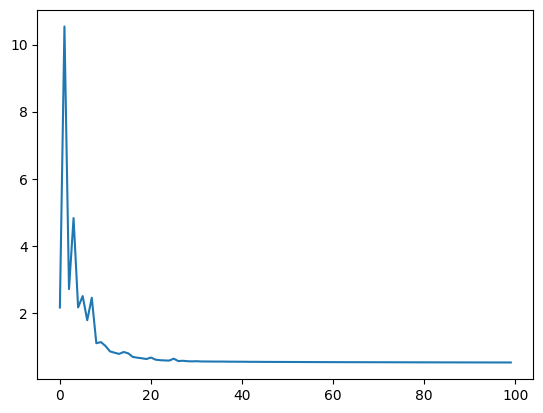

In [203]:
model.plot()
